# RFFR 03 — Refinement Comparison

Review whether any local alternative materially improves the incumbent without additional training.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "random_forest_final_refinement.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/random_forest_final_refinement.yaml')

In [3]:
# Import modules for Refinement Random Forest model 
from src.ontario_peak_risk.models.forecasting.random_forest_final_refinement.plotting import (
    mean_mae_plot,
    fold_mae_plot,
    horizon_mae_plot,
)

In [4]:
# Define config
REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "forecasting"
    / "random_forest_final_refinement"
)

details = pd.read_csv(REPORTS_DIR / "RFFR_02_refinement_details.csv")
ranking = pd.read_csv(REPORTS_DIR / "RFFR_03_refinement_ranking.csv")

display(ranking)


,refinement_id,mean_mae,std_mae,mean_rmse,mean_mape,fold_mae_range,horizon_mae_range,mae_improvement_vs_incumbent_pct,selected,decision
0,R1_more_trees,527.928931,85.732754,896.494201,5.403574,74.459833,144.432466,0.150174,False,KEEP_INCUMBENT: no local alternative exceeded ...
1,R0_incumbent,528.722937,85.719404,898.014553,5.411028,74.941850,144.295074,0.000000,True,KEEP_INCUMBENT: no local alternative exceeded ...
2,R2_leaf_3,528.771767,89.334500,899.222246,5.405014,81.230805,150.153530,-0.009235,False,KEEP_INCUMBENT: no local alternative exceeded ...
3,R3_features_08,531.514055,86.559876,902.826454,5.435193,78.172720,144.139749,-0.527898,False,KEEP_INCUMBENT: no local alternative exceeded ...


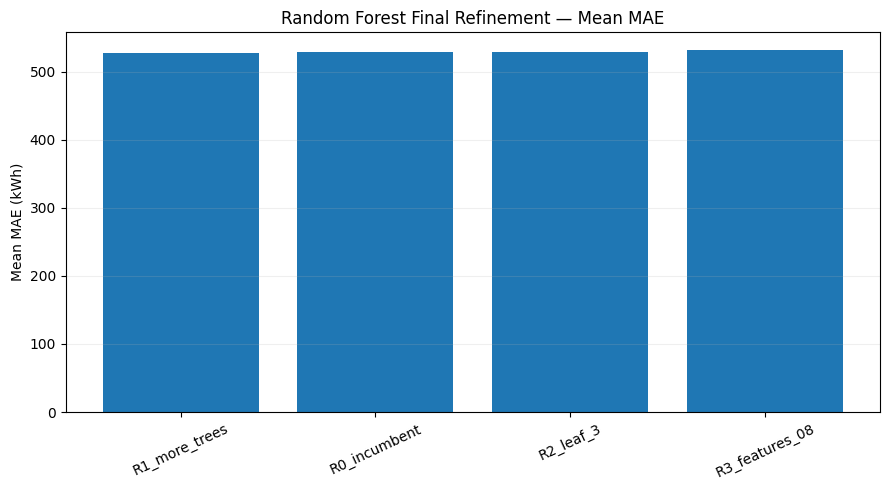

In [5]:
# Plot Ranking
mean_mae_plot(ranking); 
plt.show()

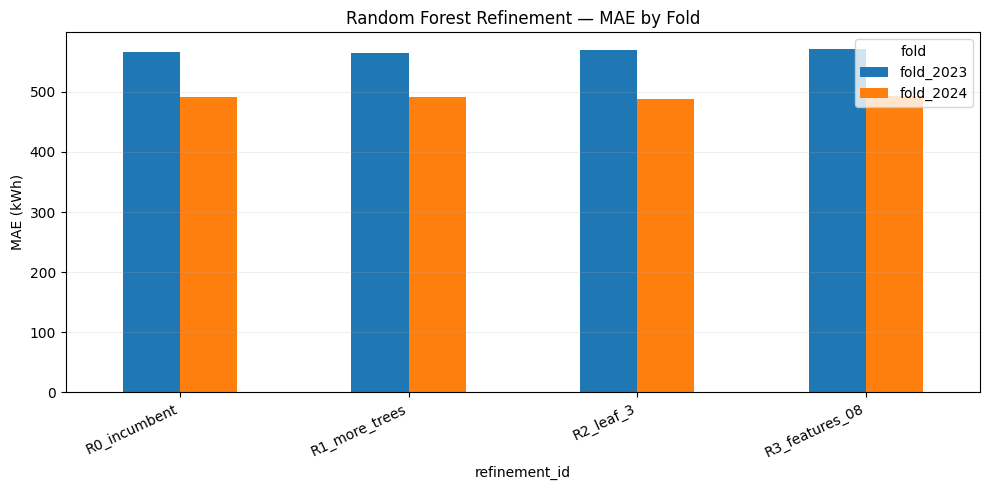

In [6]:
# Plot Flod MAE
fig = fold_mae_plot(details)
if fig is not None:
    plt.show()


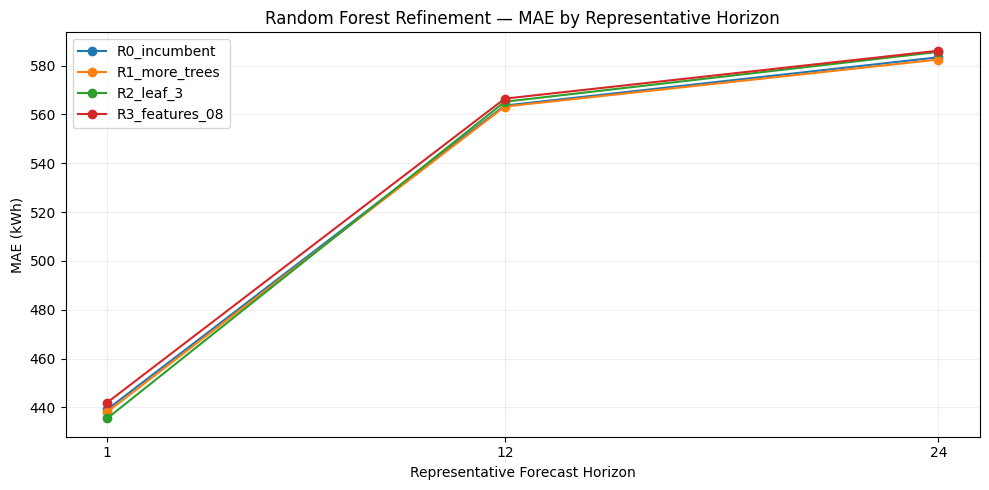

In [7]:
# Plot horizont MAE
fig = horizon_mae_plot(details)
if fig is not None:
    plt.show()


### Decision rule

A challenger replaces the incumbent only if the controlled refinement improves mean MAE by at least **0.25%**. Otherwise we keep the already-validated incumbent and proceed to freeze.